In [12]:
import mysql.connector
import numpy as np
import pandas as pd
import matplotlib.pyplot as mp

In [13]:
mydb = mysql.connector.connect(
    host = 'localhost',
    user = 'root',
    passwd = 'j0IntT@s',
    database = 'sakila'
)

In [47]:
d = {'a':[10,13,24], 'b':[12,5,1], 'c':[15,2,3],'e':[10,13,24], 'f':[12,5,1]}
pd.Series(d)

a    [10, 13, 24]
b      [12, 5, 1]
c      [15, 2, 3]
e    [10, 13, 24]
f      [12, 5, 1]
dtype: object

In [27]:
randomtrial = np.random.randn(5,6)
c = pd.DataFrame(randomtrial, index=['a', 'b', 'c', 'd', 'e'], columns=['a', 'b', 'c', 'd', 'e', 'f'])
print(c)

          a         b         c         d         e         f
a  0.641717  1.933389 -0.802441  2.177707  1.074478 -1.825258
b -0.149491 -0.736988 -0.286823 -0.928688  0.594029 -0.796353
c -1.319236  0.498388 -2.012098 -0.314806 -0.342198 -1.504804
d  1.666010 -0.897195  0.756417 -0.585153  0.388433  0.881200
e  0.596791 -0.243488 -0.381780 -0.617473 -0.243531  0.317357


In [39]:
c['g']=[2,1,0,2,3]
c['g'] = [22.22, 1,2,0,-1]

In [48]:
df = pd.read_csv('global_gdp_inflation_2000_2024.csv')

In [110]:
df

,Year,Country,ISO3,GDP_Growth_Percent,Inflation_Percent,Data_Type,Source
0,2001,Afghanistan,AFG,-9.431974,NaN,Historical,World Bank API
1,2002,Afghanistan,AFG,28.600001,NaN,Historical,World Bank API
2,2003,Afghanistan,AFG,8.832278,NaN,Historical,World Bank API
3,2004,Afghanistan,AFG,1.414118,NaN,Historical,World Bank API
4,2005,Afghanistan,AFG,11.229715,12.686269,Historical,World Bank API
...,...,...,...,...,...,...,...
5199,2020,Zimbabwe,ZWE,-7.816951,557.201817,Historical,World Bank API
5200,2021,Zimbabwe,ZWE,8.468017,98.546105,Historical,World Bank API
5201,2022,Zimbabwe,ZWE,6.139263,104.705171,Historical,World Bank API
5202,2023,Zimbabwe,ZWE,5.350869,NaN,Historical,World Bank API


In [89]:
indo_Growth = df[
    (df['Country'] == 'Indonesia') &
    (df['Year'].between(2000,2024))]
indo_Growth.head(25)

,Year,Country,ISO3,GDP_Growth_Percent,Inflation_Percent,Data_Type,Source
2145,2000,Indonesia,IDN,4.920068,3.688620,Historical,World Bank API
2146,2001,Indonesia,IDN,3.643466,11.500116,Historical,World Bank API
2147,2002,Indonesia,IDN,4.499475,11.900120,Historical,World Bank API
2148,2003,Indonesia,IDN,4.780369,6.757313,Historical,World Bank API
2149,2004,Indonesia,IDN,5.030874,6.064062,Historical,World Bank API
2150,2005,Indonesia,IDN,5.692571,10.453200,Historical,World Bank API
2151,2006,Indonesia,IDN,5.500952,13.108671,Historical,World Bank API
2152,2007,Indonesia,IDN,6.345022,6.406561,Historical,World Bank API
2153,2008,Indonesia,IDN,6.013704,10.226666,Historical,World Bank API
2154,2009,Indonesia,IDN,4.628871,4.386413,Historical,World Bank API


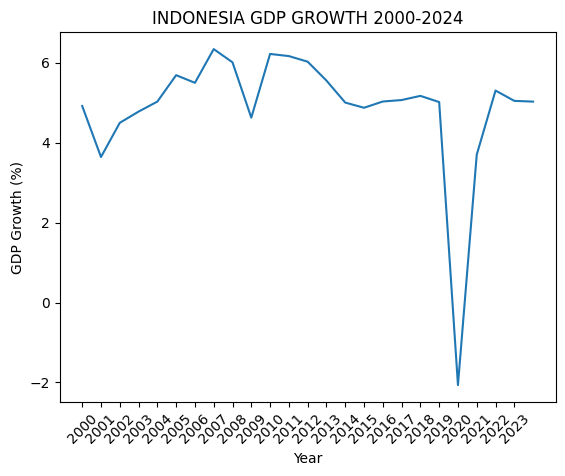

In [101]:
mp.plot(indo_Growth['Year'], indo_Growth['GDP_Growth_Percent'])
# mp.xticks(indo_Growth['Year'], rotation =45) #rotation itu tulisan x nya aja, xticks itu force tick(tanda) per 'Year'
years = indo_Growth['Year']
mp.xticks(np.arange(years.min(), years.max()), rotation=45)
mp.xlabel('Year')
mp.ylabel('GDP Growth (%)')
mp.title("INDONESIA GDP GROWTH 2000-2024")
mp.show()

In [154]:
df1 = df[['Country', 'Year', 'GDP_Growth_Percent', 'Source']]
pivotdf1 = df1.pivot_table(index = 'Country', columns = 'Year', aggfunc='mean', values='GDP_Growth_Percent')
pivotdfINDO = (df[df['Country'] == 'Indonesia'].pivot_table(index = ['Country', 'Source'], columns = 'Year', values='GDP_Growth_Percent'))
display(pivotdfINDO)

,Year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Country,Source,,,,,,,,,,,,,,,,,,,,,
Indonesia,World Bank API,4.920068,3.643466,4.499475,4.780369,5.030874,5.692571,5.500952,6.345022,6.013704,4.628871,...,4.876322,5.033069,5.069786,5.174292,5.019288,-2.065512,3.702886,5.307197,5.049023,5.030345
